### Taller de Preparación

**Objetivo**: Desarrollar habilidades prácticas en análisis exploratorio de datos, preprocesamiento, balanceo de datos, y entrenamiento y evaluación de modelos de machine learning.

**Base de Datos**: "Bank Marketing".

**Descripción de la Base de Datos**:
- Relacionado con campañas de marketing directo (llamadas telefónicas) de una institución bancaria.
- **Objetivo**: Predecir si el cliente suscribirá un depósito a plazo.






**Enunciado**:
1. **Análisis Exploratorio de Datos (EDA)**:
   - Realiza un análisis exploratorio completo para entender las características y la relación entre ellas.
   - Identifica patrones, anomalías, variables importantes y correlaciones que puedan influir en el resultado del modelo.

In [1]:
# montar drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, roc_curve, auc
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



In [3]:
# cargar archivo de excel

# -----------------------------
# Reading the database
# -----------------------------
file_path = '/content/drive/My Drive/Curso Mineria de Datos 2024/Semana 6 - Ensambles/bank-full.csv'

# Load the data
data = pd.read_csv(file_path, sep=';')

In [4]:
# Análisis Exploratorio de Datos (EDA)
print(data.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [6]:
data.shape

(45211, 17)

In [7]:
data.isnull().sum()


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [8]:
data.job.unique()


array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [9]:
data.marital.unique()

array(['married', 'single', 'divorced'], dtype=object)

In [10]:
data.education.value_counts()

,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


In [11]:
data.loan.value_counts()


,count
loan,
no,37967
yes,7244


<Axes: xlabel='y', ylabel='count'>

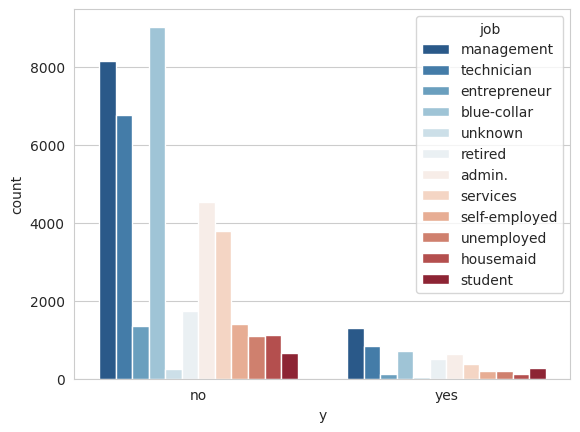

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')
sns.countplot(x='y',hue='job',data=data,palette='RdBu_r')

<Axes: xlabel='y', ylabel='count'>

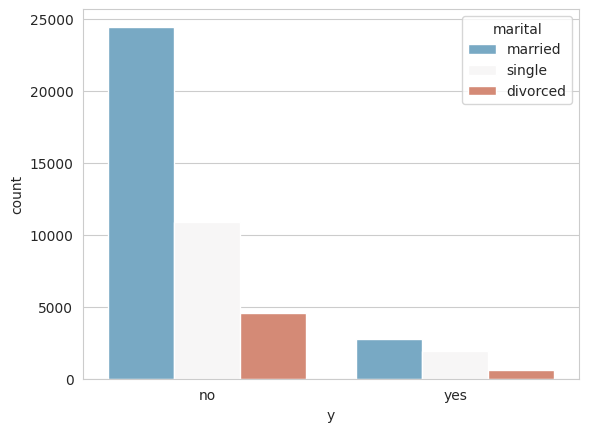

In [13]:
sns.set_style('whitegrid')
sns.countplot(x='y',hue='marital',data=data,palette='RdBu_r')

<Axes: xlabel='y', ylabel='count'>

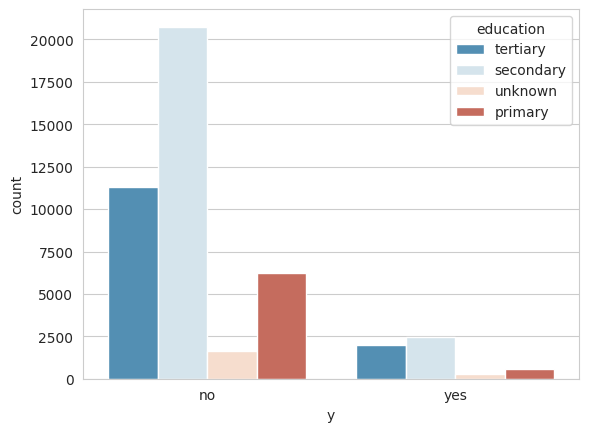

In [14]:
sns.set_style('whitegrid')
sns.countplot(x='y',hue='education',data=data,palette='RdBu_r')

In [15]:
# defining a function to get distribution and outliers
def distributions(data, variable):
    # Configuración del estilo
    sns.set(style="whitegrid")

    # Crear la figura con dos subplots, una al lado de la otra
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Gráfica de densidad en el primer subplot
    sns.kdeplot(data[variable], ax=axes[0], color='red', fill=True)
    axes[0].set_title(f'Distribución de Densidad de {variable}')
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel('Densidad')

    # Diagrama de caja en el segundo subplot
    sns.boxplot(x=data[variable], ax=axes[1], color='green')
    axes[1].set_title(f'Diagrama de Caja de {variable}')
    axes[1].set_xlabel(variable)

    # Ajustar la disposición de la figura
    plt.tight_layout()
    plt.show()

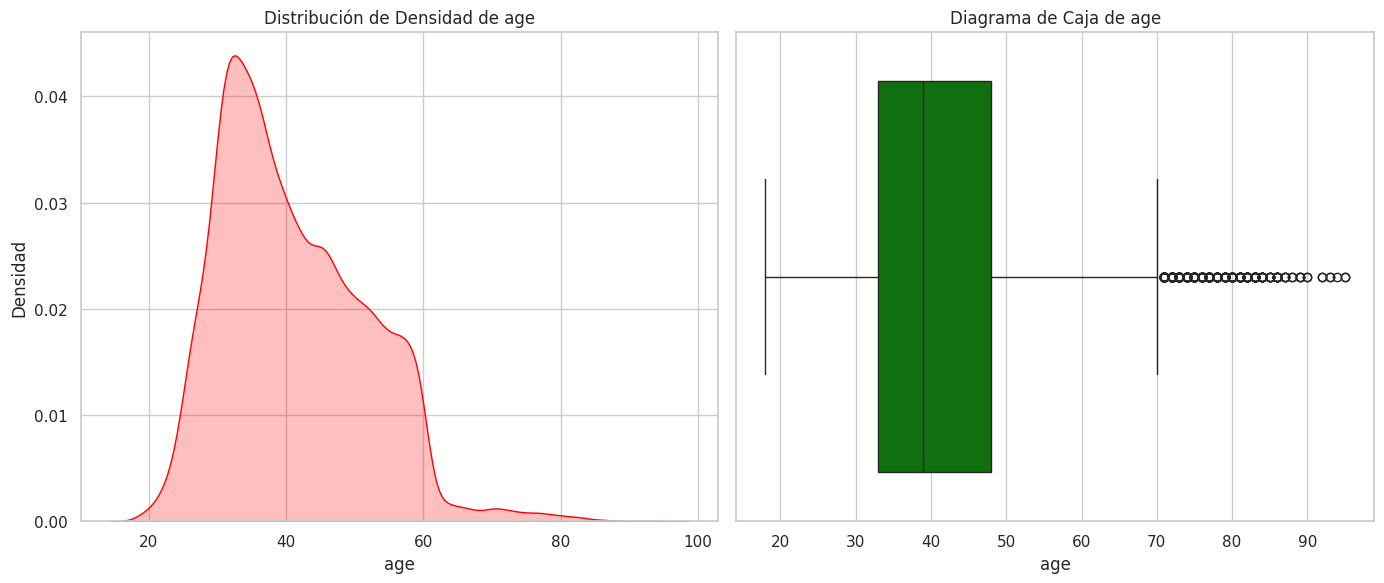

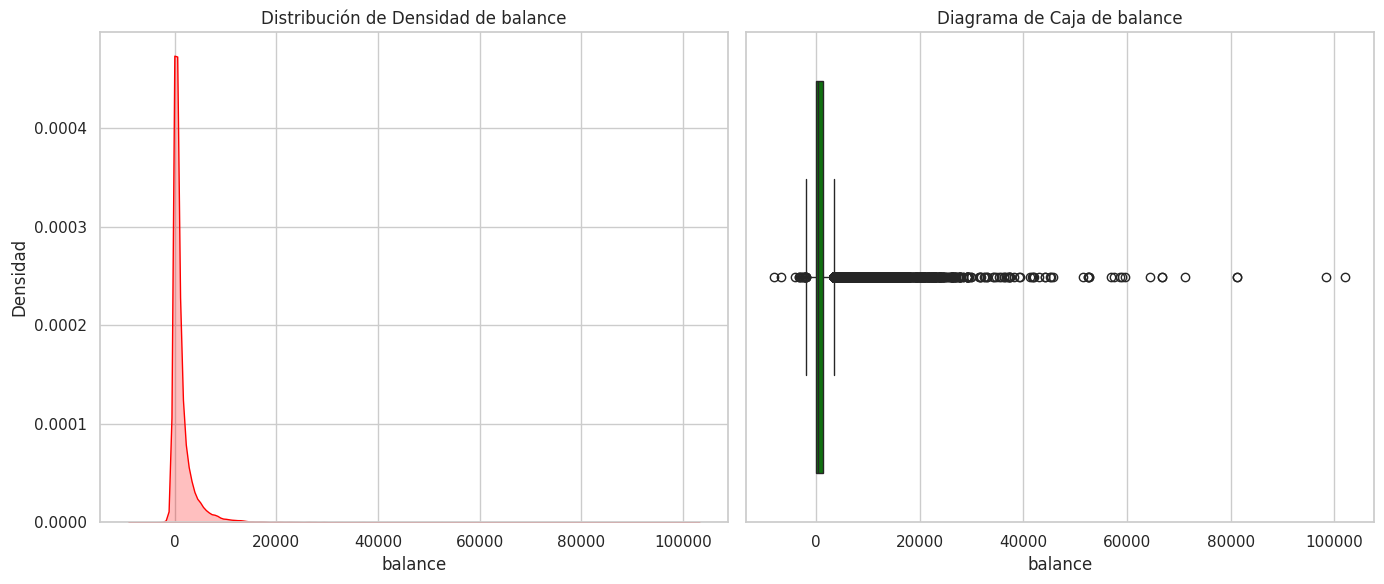

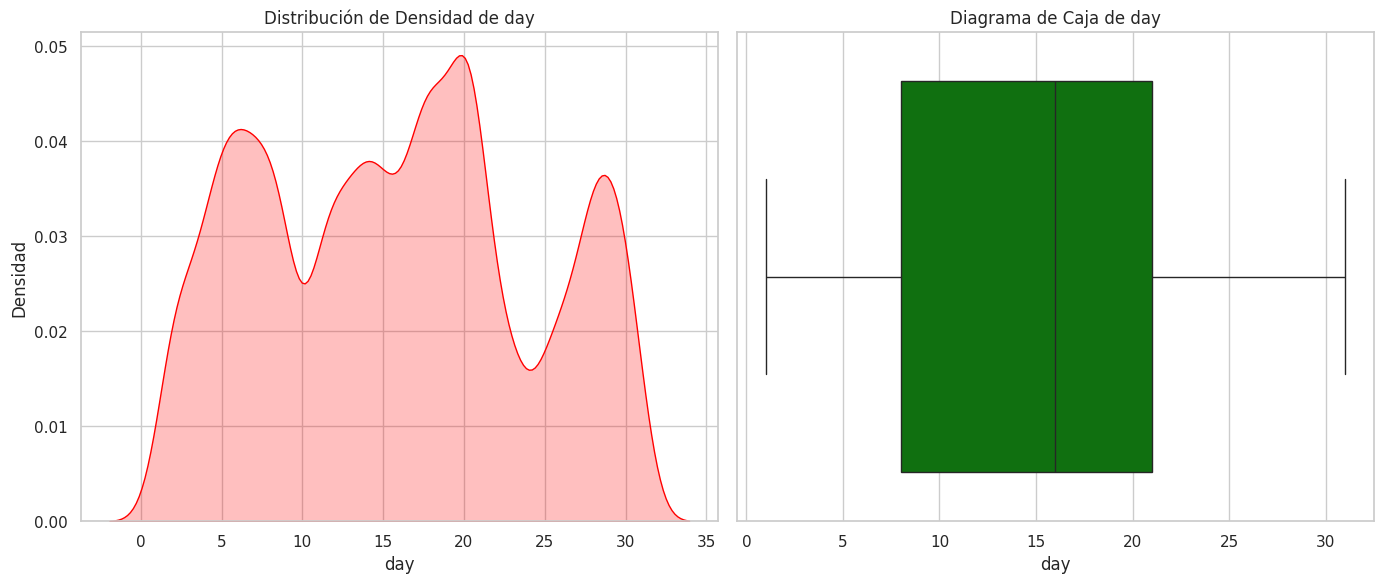

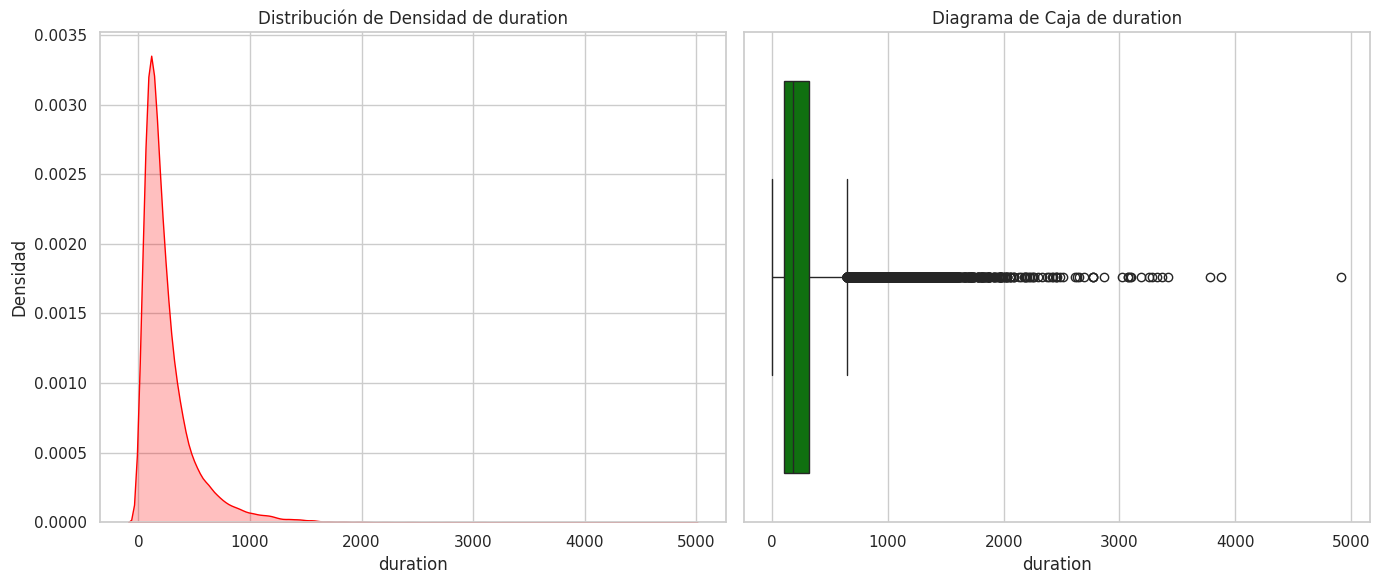

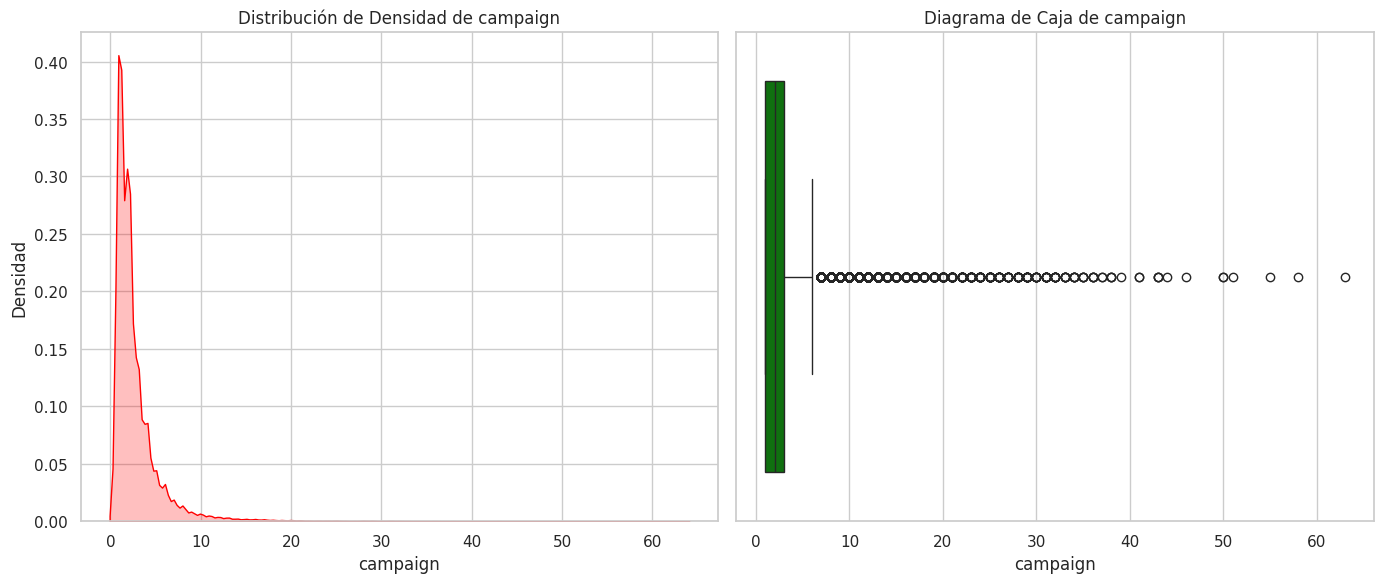

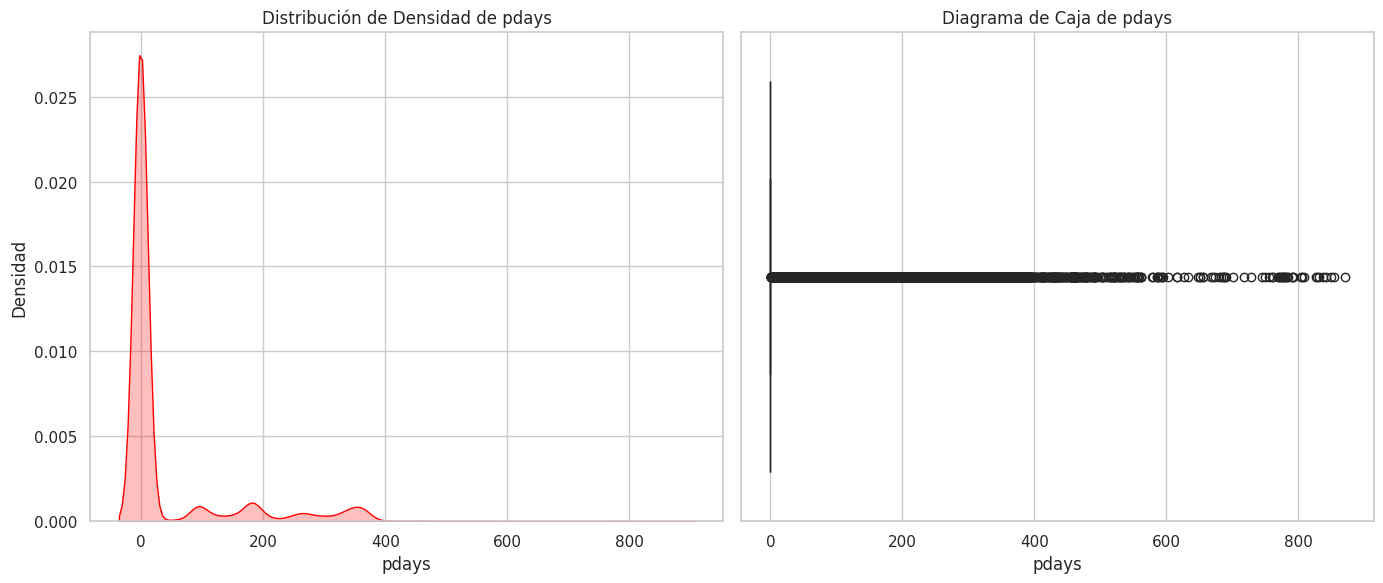

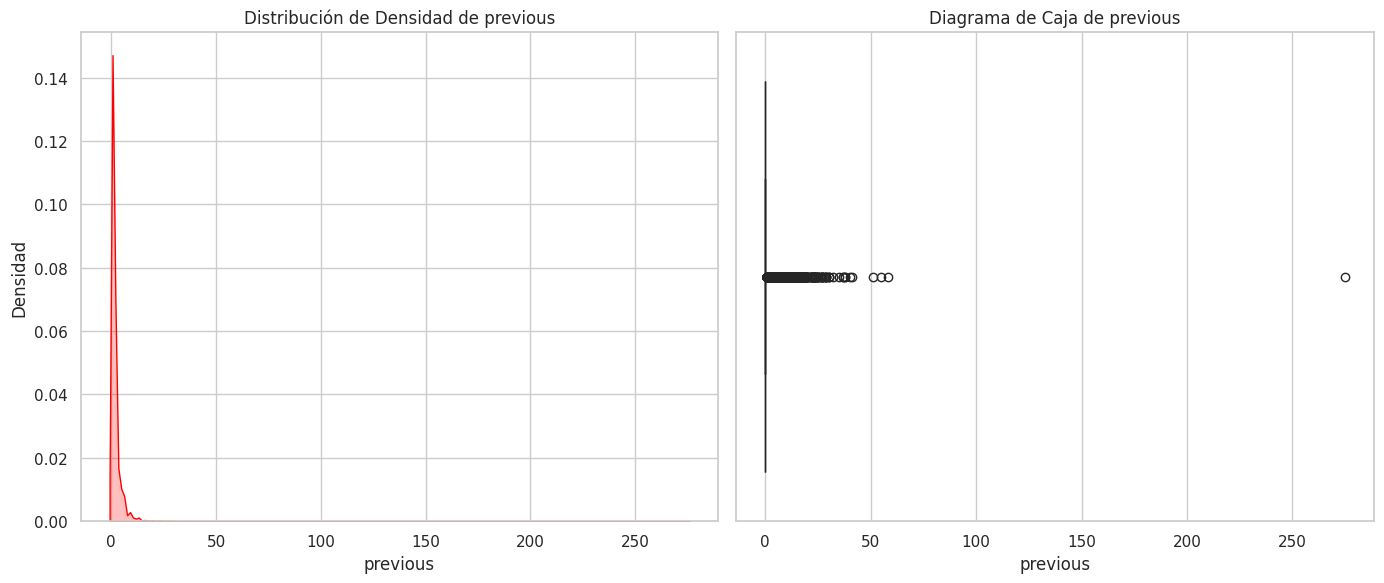

In [16]:
# Iterar sobre cada columna numérica en el DataFrame
for column in data.select_dtypes(include=[np.number]).columns:
    distributions(data, column)


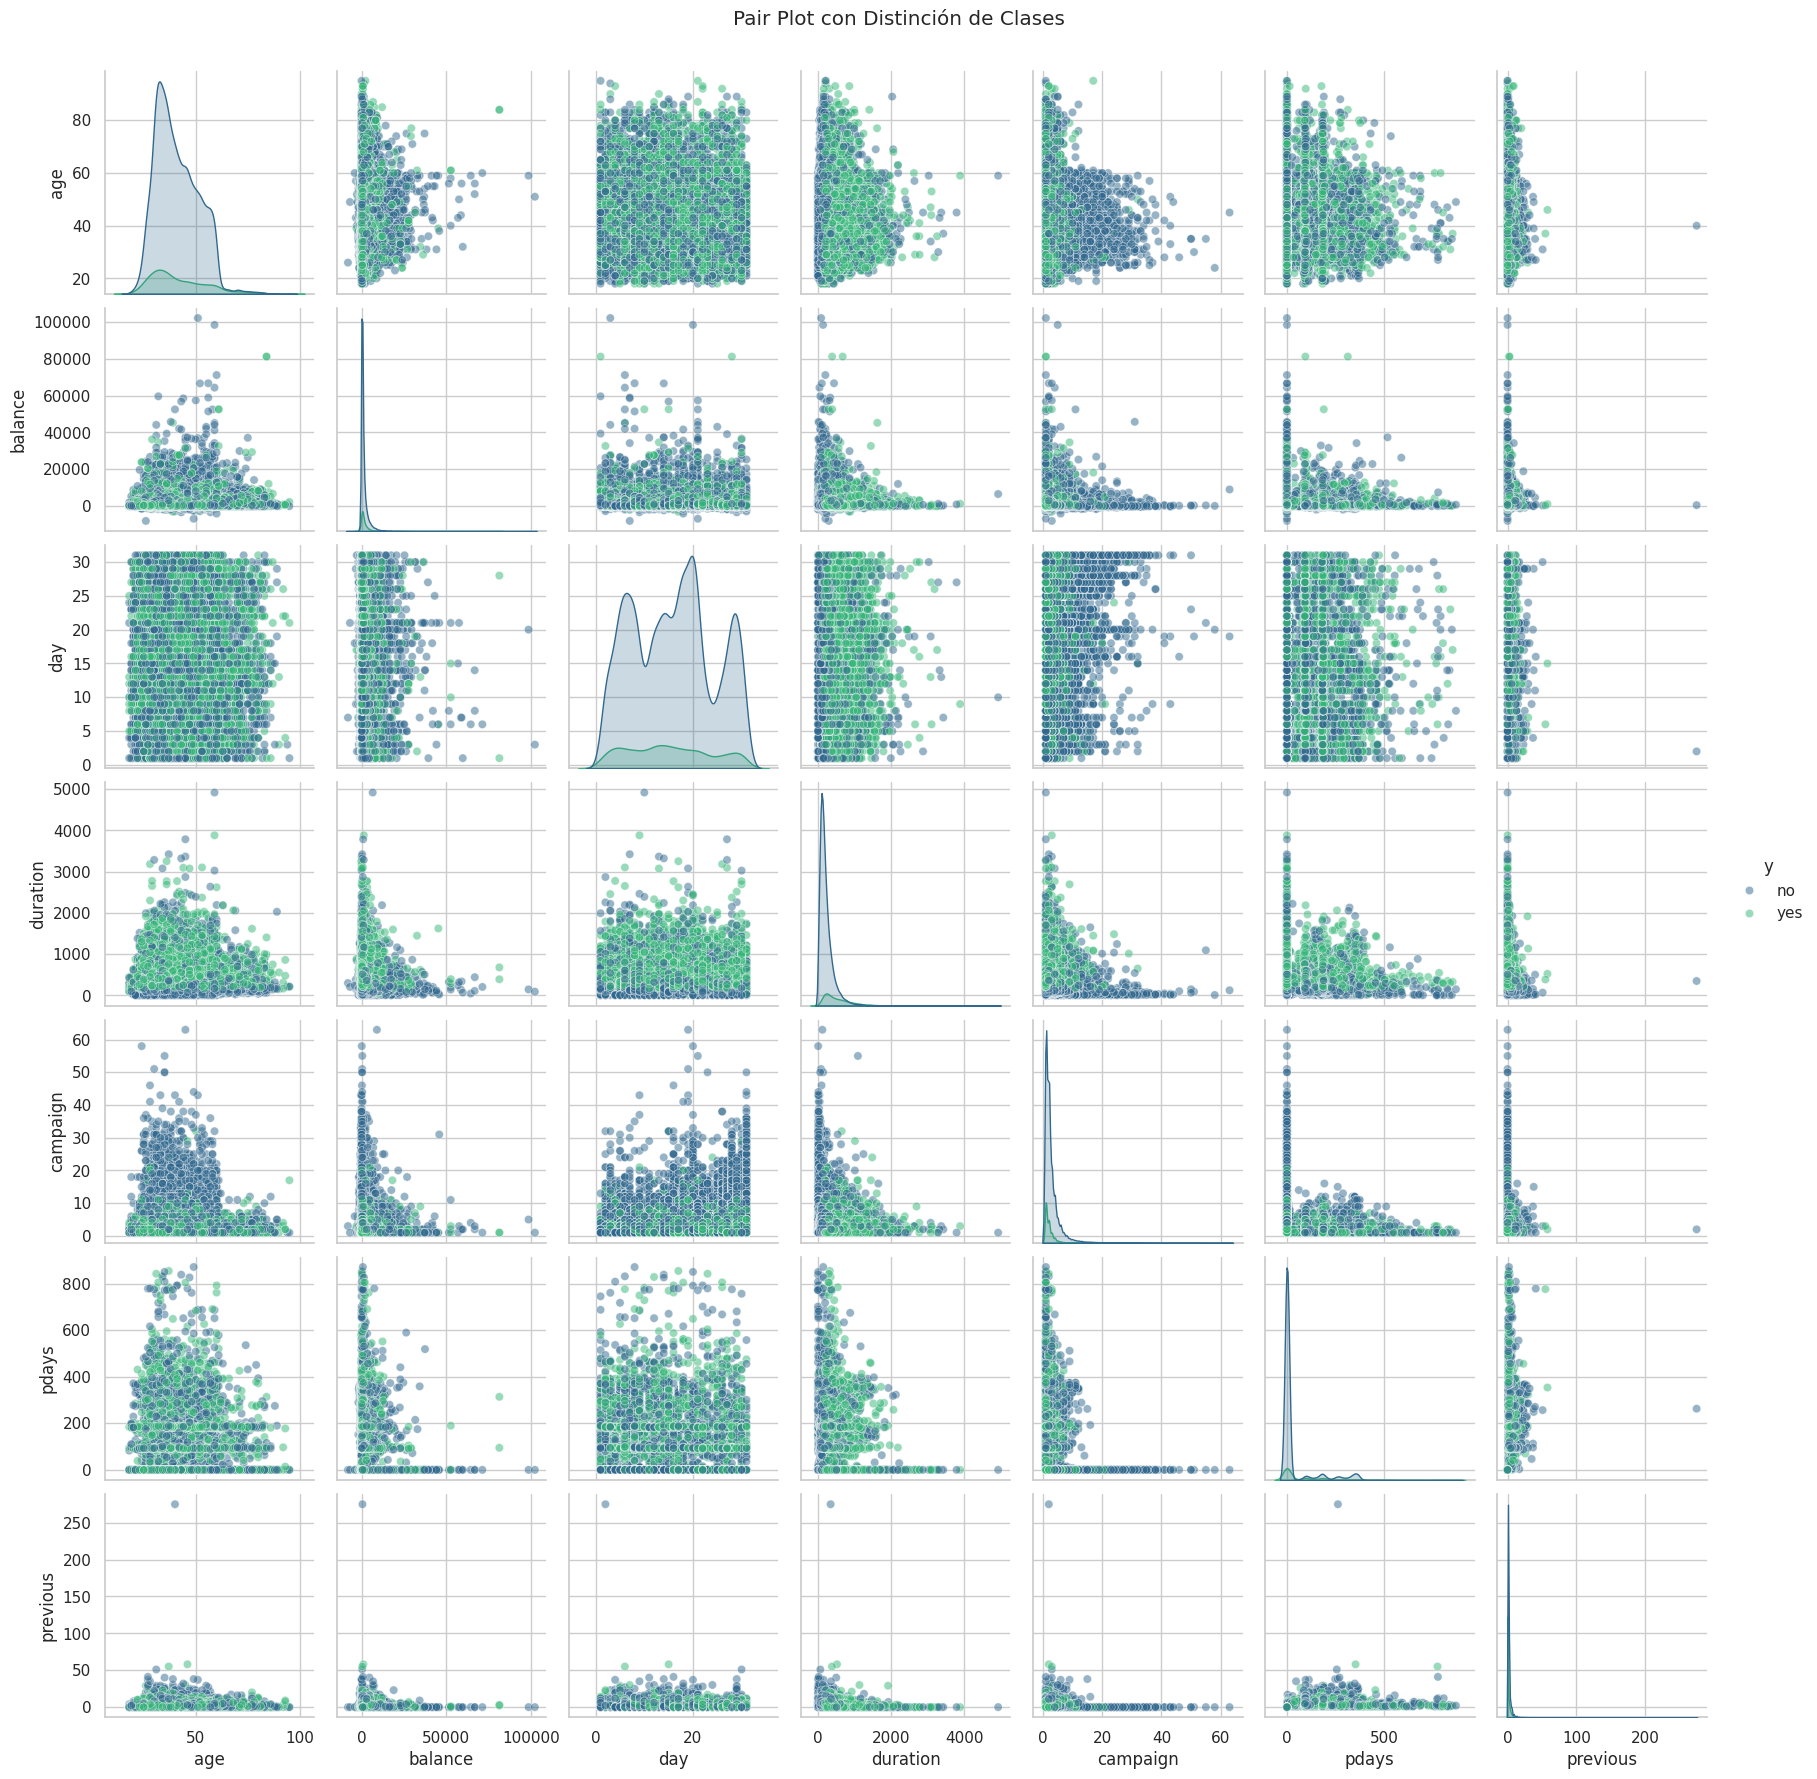

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def pairplot_with_class_distinction(data, target):
    # Selección de variables numéricas más la columna objetivo
    num_data = data.select_dtypes(include=[np.number])
    num_data[target] = data[target]  # Incluir la columna de etiquetas para colorear según la clase

    # Configuración del estilo de fondo de seaborn
    sns.set(style="whitegrid")

    # Crear un pair plot
    pairplot = sns.pairplot(num_data, hue=target, palette='viridis', plot_kws={'alpha': 0.5})

    # Añadir títulos y configurar los ejes
    pairplot.fig.suptitle('Pair Plot con Distinción de Clases', y=1.02)

    plt.show()


# Llamar a la función para generar el pair plot con distinción de clases
pairplot_with_class_distinction(data, 'y')



In [18]:
data[["day", "month","pdays"]].head(5)

,day,month,pdays
0,5,may,-1
1,5,may,-1
2,5,may,-1
3,5,may,-1
4,5,may,-1


Las columnas day y month pueden ser eliminadas porque su información esta contenida en la columna pdays.

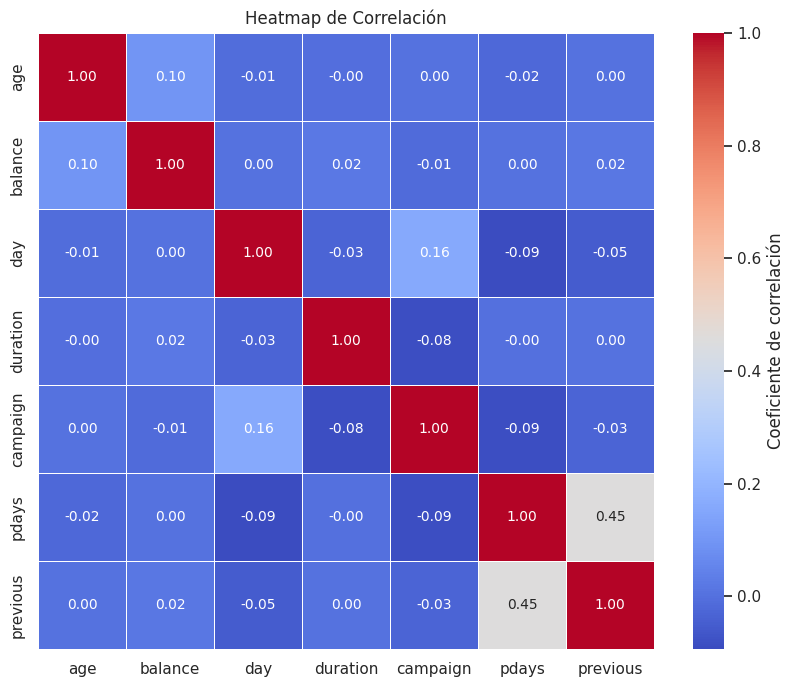

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(data):
    # Selección de variables numéricas
    num_data = data.select_dtypes(include=[np.number])

    # Calcular la matriz de correlación
    correlation_matrix = num_data.corr()

    # Crear un heatmap de las correlaciones
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',
                cbar_kws={'label': 'Coeficiente de correlación'},
                square=True, linewidths=.5, annot_kws={"size": 10})
    plt.title('Heatmap de Correlación')
    plt.show()


# Llamar a la función para generar el heatmap de correlación
plot_correlation_heatmap(data)


2. **Preprocesamiento**:
   - Aplica técnicas de limpieza y preprocesamiento adecuadas basadas en tu EDA.
   - Considera la codificación de variables categóricas, la normalización o estandarización de variables numéricas y el manejo de valores faltantes.



In [20]:
data_1 = data.copy()

In [21]:
data_1.drop(["day","month"],axis =1, inplace = True)

In [22]:
# changing unknown with null values (because "unknown" has no information)
for i in data_1.columns:
    data_1[i] = np.where(data_1[i] == "unknown", np.nan, data_1[i])

data_1.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
duration,0


In [23]:
# proportion of null per colum
data_1.isna().sum() / len(data_1)

,0
age,0.000000
job,0.006370
marital,0.000000
education,0.041074
default,0.000000
balance,0.000000
housing,0.000000
loan,0.000000
contact,0.287983
duration,0.000000


In [24]:
# dropping the feature with higher percentage of null values
data_1.drop("poutcome", inplace = True, axis = 1)

In [25]:
data_1.drop("contact", inplace = True, axis = 1)

In [26]:
# Convertir la variable objetivo 'y' de categoría a numérica
data_1['y'] = data['y'].map({'yes': 1, 'no': 0}).astype(int)

In [27]:
data_1.head()

,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,y
0,58.0,management,married,tertiary,no,2143.0,yes,no,261.0,1.0,-1.0,0.0,0
1,44.0,technician,single,secondary,no,29.0,yes,no,151.0,1.0,-1.0,0.0,0
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,76.0,1.0,-1.0,0.0,0
3,47.0,blue-collar,married,NaN,no,1506.0,yes,no,92.0,1.0,-1.0,0.0,0
4,33.0,NaN,single,NaN,no,1.0,no,no,198.0,1.0,-1.0,0.0,0


In [ ]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        44923 non-null  object 
 2   marital    45211 non-null  object 
 3   education  43354 non-null  object 
 4   default    45211 non-null  object 
 5   balance    45211 non-null  float64
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  pdays      45211 non-null  float64
 11  previous   45211 non-null  float64
 12  y          45211 non-null  int64  
dtypes: float64(6), int64(1), object(6)
memory usage: 4.5+ MB


In [30]:

X_train, X_test, y_train, y_test = train_test_split(data_1.drop('y', axis=1), data_1['y'], test_size=0.2, random_state=42, stratify=data_1['y'])

In [31]:
from scipy.stats import skew
# Identificar asimetría de las variables numéricas
numeric_features = data_1.drop('y', axis=1).select_dtypes(include=['int64', 'float64']).columns
skewness = data_1[numeric_features].apply(lambda x: skew(x.dropna()))
high_skew = skewness[skewness > 1].index.tolist()
low_skew = skewness[skewness <= 1].index.tolist()


In [32]:
numeric_features

Index(['age', 'balance', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [33]:
high_skew

['balance', 'duration', 'campaign', 'pdays', 'previous']

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Imputación y estandarización para todas las variables numéricas
standard_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Transformación adicional de potencia para variables con alta asimetría
power_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# Transformaciones para variables categóricas
categorical_features = ['job', 'marital', 'default', 'housing', 'loan']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# Transformación especial para 'education' con Ordinal Encoder
education_levels = [['primary', 'secondary', 'tertiary']]
education_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['primary', 'secondary', 'tertiary']]))
])


In [35]:
# ColumnTransformer que incluye todas las transformaciones
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num_high_skew', power_transformer, high_skew),
        ('num_low_skew', standard_transformer, low_skew),
        ('edu', education_transformer, ['education']),
        ('cat', categorical_transformer, categorical_features)],remainder='passthrough')

In [36]:
# ColumnTransformer que incluye todas las transformaciones
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('edu', education_transformer, ['education']),
        ('cat', categorical_transformer, categorical_features)
    ],remainder='passthrough')

3. **Evaluación de Balanceo de Datos**:
   - Evalúa la necesidad de aplicar técnicas de balanceo de datos. Implementa y compara los resultados con y sin balanceo.



<ipython-input-37-729c79d6be1d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y',data=data_1,palette='RdBu_r')


<Axes: xlabel='y', ylabel='count'>

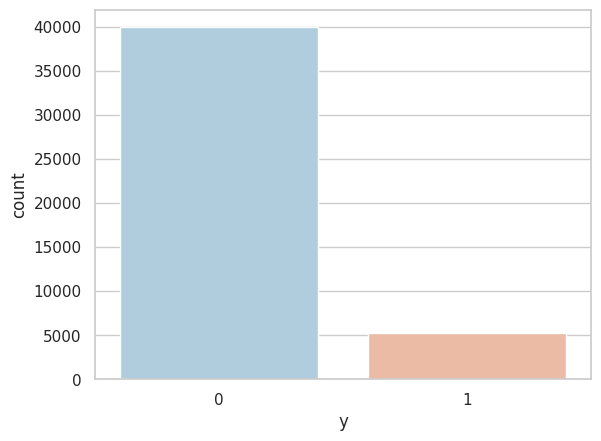

In [37]:
sns.set_style('whitegrid')
sns.countplot(x='y',data=data_1,palette='RdBu_r')

La recomendaciòn es realizar alguna técnica de submuestreo, teniendo en cuenta que tenemos una base de datos amplia y que la clase de interes es minoritaría y resultaría muy difícil crear  tantos sinteticos.

3.2 comparelo con el mejor algoritmo sin submestrear que obtenga de los puntos 4 y 5.

**Accuracy: 0.8844**

4. **Modelado y Optimización de Hiperparámetros**:
   - **Modelos a entrenar**: Regresión Logística, Regresión Lasso/Ridge (Regularizados), SVM y Árboles de Decisión.
   - Utiliza técnicas de optimización de hiperparámetros como Grid Search y Random Search dentro de una validación cruzada para encontrar la mejor configuración.

In [38]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# 6. Implementar el undersampling con RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)


In [39]:
# 7. Crear el pipeline completo con undersampling y el modelo (LogisticRegression por ejemplo)
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('undersampler', undersampler),  # Aquí se añade el undersampling
    ('classifier', LogisticRegression(solver='liblinear'))
])

# 8. Definir el espacio de búsqueda de hiperparámetros para RandomizedSearchCV
param_distributions = {
    'classifier__C': uniform(loc=0, scale=4),  # Espacio de búsqueda para C
}

# 9. Implementar RandomizedSearchCV para reducir el tiempo de búsqueda
random_search = RandomizedSearchCV(pipeline, param_distributions, n_iter=10, scoring='roc_auc', n_jobs=-1, cv=5, random_state=42)

# 10. Entrenar el modelo con el pipeline completo y búsqueda de hiperparámetros
random_search.fit(X_train, y_train)

# 11. Evaluar el modelo
print("Mejores parámetros encontrados: ", random_search.best_params_)
print("Mejor AUC obtenido: ", random_search.best_score_)


Mejores parámetros encontrados:  {'classifier__C': 3.8028572256396647}
Mejor AUC obtenido:  0.8768067331319394


In [40]:
y_pred = random_search.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     31937
           1       0.34      0.81      0.48      4231

    accuracy                           0.79     36168
   macro avg       0.65      0.80      0.67     36168
weighted avg       0.90      0.79      0.82     36168



In [41]:
# Configuración de hiperparámetros para GridSearch
param_grid_logistic = {'classifier__C': [0.01, 0.1, 1, 10, 100]}  # LogisticRegression usa 'C' para regularización
param_grid_ridge = {'classifier__alpha': [0.1, 1, 10, 100, 1000]}  # RidgeClassifier usa 'alpha' para regularización
param_grid_lasso = {'classifier__C': [0.1, 1, 10, 100, 1000]}  # LogisticRegression con L1 (equivalente a Lasso en clasificación)
param_grid_svm = {'classifier__C': [0.1, 1, 10, 100], 'classifier__gamma': [0.01, 0.1, 1, 10]}  # SVM
param_grid_tree = {'classifier__max_depth': [None, 10, 20, 50], 'classifier__min_samples_split': [2, 10, 50]}  # DecisionTreeClassifier

# Pipelines para cada modelo
pipeline_logistic = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('classifier', LogisticRegression())
])

pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('classifier', RidgeClassifier())
])

pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear'))  # Usar LogisticRegression con penalización L1
])

pipeline_svm = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('classifier', SVC())
])

pipeline_tree = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier())
])

# Configuración de GridSearchCV para cada modelo
grid_logistic = RandomizedSearchCV(pipeline_logistic, param_grid_logistic, cv=5, scoring='accuracy')
grid_ridge = RandomizedSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring='accuracy')
grid_lasso = RandomizedSearchCV(pipeline_lasso, param_grid_lasso, cv=5, scoring='accuracy')
grid_svm = RandomizedSearchCV(pipeline_svm, param_grid_svm, cv=5, scoring='accuracy')
grid_tree = RandomizedSearchCV(pipeline_tree, param_grid_tree, cv=5, scoring='accuracy')


In [42]:

# Entrenar cada modelo usando GridSearchCV
grid_logistic.fit(X_train, y_train)
grid_ridge.fit(X_train, y_train)
#grid_lasso.fit(X_train, y_train)
#grid_svm.fit(X_train, y_train)
grid_tree.fit(X_train, y_train)

# Mostrar los mejores parámetros y los mejores scores
print("Best parameters for Logistic Regression:", grid_logistic.best_params_)
print("Best score for Logistic Regression:", grid_logistic.best_score_)

print("Best parameters for Ridge:", grid_ridge.best_params_)
print("Best score for Ridge:", grid_ridge.best_score_)


# print("Best parameters for Lasso:", grid_lasso.best_params_)
# print("Best score for Lasso:", grid_lasso.best_score_)

# print("Best parameters for SVM:", grid_svm.best_params_)
# print("Best score for SVM:", grid_svm.best_score_)

print("Best parameters for Decision Tree:", grid_tree.best_params_)
print("Best score for Decision Tree:", grid_tree.best_score_)


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for Logistic Regression: {'classifier__C': 0.1}
Best score for Logistic Regression: 0.8925293675758293
Best parameters for Ridge: {'classifier__alpha': 1}
Best score for Ridge: 0.8847876104364687
Best parameters for Decision Tree: {'classifier__min_samples_split': 50, 'classifier__max_depth': 10}
Best score for Decision Tree: 0.8936353443485704



*Los siguientes puntos puedes intentarlos, pero quedaràn mas claros la próxima clase*

5. **Evaluación de Modelos y Diagnóstico de Ajuste**:
   - Evalúa los modelos utilizando curvas ROC, AUC, precisión, recall, F1-score, y curvas de aprendizaje para detectar si hay subajuste o sobreajuste.
   - Basado en un enfoque de validación cruzada, decide cuál algoritmo y coon que hiperparámetros se ofrece el mejor equilibrio entre sesgo y varianza sin tener acceso a los datos de prueba.


In [44]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

# Función para evaluar los modelos
def evaluate_model(model, X_test, y_test):
    # Predecir las etiquetas
    y_pred = model.predict(X_test)

    # Calcular las probabilidades
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Precisión, recall, f1-score
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Imprimir resultados
    print(f"Precisión: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # AUC-ROC
    if y_prob is not None:
        auc_score = roc_auc_score(y_test, y_prob)
        print(f"AUC-ROC: {auc_score:.4f}")

        # Graficar la curva ROC utilizando RocCurveDisplay
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title('Curva ROC')
        plt.show()


# Función para graficar curvas de aprendizaje
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title):
    plt.figure()
    plt.title(title)

    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))

    # Calcular media y desviación estándar
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.xlabel("Número de ejemplos de entrenamiento")
    plt.ylabel("Precisión")
    plt.legend(loc="best")
    plt.grid()
    plt.show()





Evaluación del modelo: Logistic Regression
Precisión: 0.5965
Recall: 0.2564
F1-Score: 0.3587
AUC-ROC: 0.8781


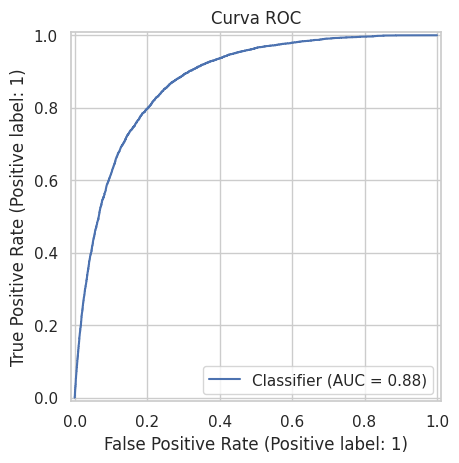

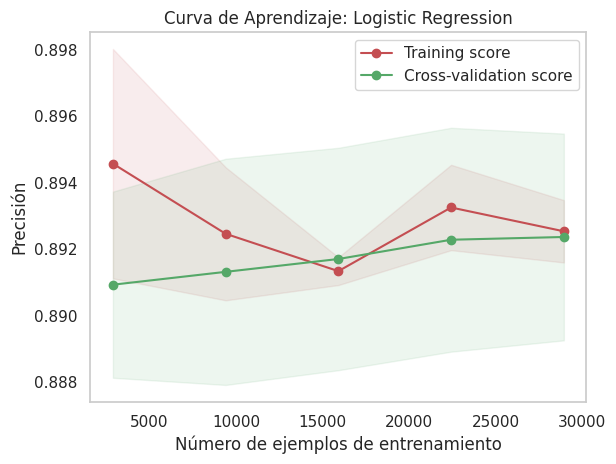


Evaluación del modelo: Ridge Classifier
Precisión: 0.6555
Recall: 0.0324
F1-Score: 0.0617


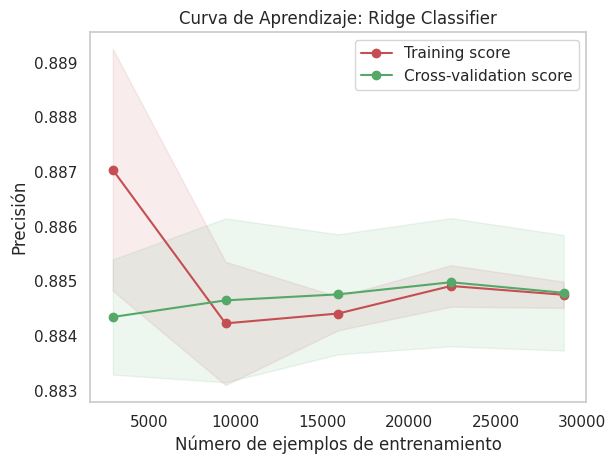


Evaluación del modelo: Decision Tree
Precisión: 0.6829
Recall: 0.4550
F1-Score: 0.5461
AUC-ROC: 0.9123


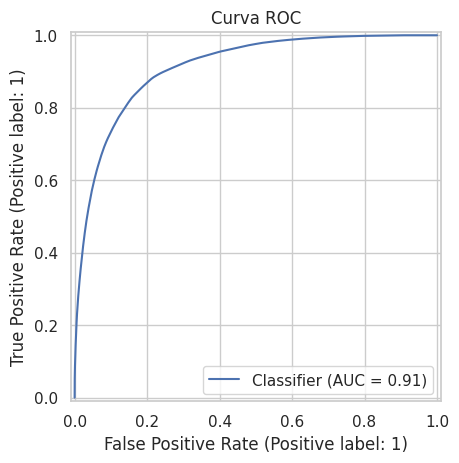

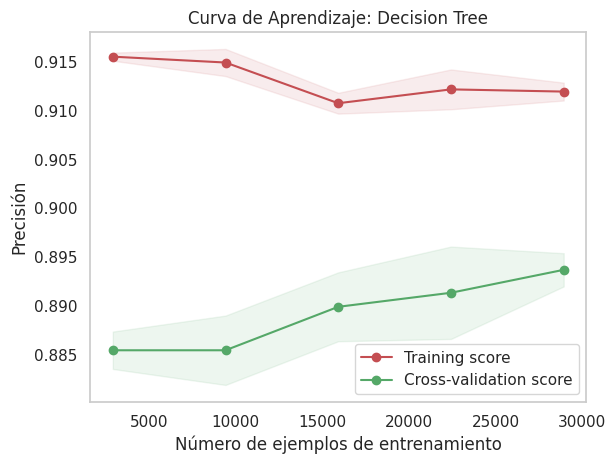

In [45]:
# Evaluar cada modelo y mostrar las curvas de aprendizaje
models = {
    'Logistic Regression': grid_logistic.best_estimator_,
    'Ridge Classifier': grid_ridge.best_estimator_,
    #'Lasso (Logistic Regression L1)': grid_lasso.best_estimator_,
    #'SVM': grid_svm.best_estimator_,
    'Decision Tree': grid_tree.best_estimator_
}

for model_name, model in models.items():
    print(f"\nEvaluación del modelo: {model_name}")
    evaluate_model(model, X_train, y_train)
    plot_learning_curve(model, X_train, y_train, title=f'Curva de Aprendizaje: {model_name}')


6. **Selección del Mejor Modelo**:
   - Elige el algoritmos que consideres que generalizará mejor en datos no vistos, basándote en tu análisis detallado y las métricas de evaluación.
   - Justifica tu elección explicando cómo este modelo y sus parámetros son los más adecuados para los datos y el problema en cuestión. Por último usa tus datos de testeo y concluye con base en las métricas obtenidas con el mejor modelo.


In [2]:
!pip install scikit-posthocs

In [4]:
from sklearn.model_selection import cross_val_score
from scipy.stats import friedmanchisquare, wilcoxon
import scikit_posthocs as sp
from sklearn.model_selection import cross_val_score
from scipy.stats import friedmanchisquare, wilcoxon
import scikit_posthocs as sp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Inicializar el diccionario para almacenar resultados
cv_results = {}

# Iterar sobre cada modelo, calcular el cross-validation score y almacenar los resultados
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[model_name] = cv_scores

# Convertir los resultados en un DataFrame
cv_scores_df = pd.DataFrame(cv_results)

# Visualizar los resultados como un boxplot
sns.boxplot(data=cv_scores_df)
plt.title('Cross-Validation Scores for Each Model')
plt.ylabel('Accuracy')
plt.show()


NameError: name 'models' is not defined

In [ ]:
# Paso 6: Comparación de los algoritmos usando el Test de Friedman
scores_friedman = np.array([cv_results[model] for model in models])
stat, p_value = friedmanchisquare(*scores_friedman)

print(f'Friedman Test Statistic: {stat}')
print(f'p-value: {p_value}\n')

In [ ]:
# Siga con el código!!!